In [9]:
import itertools
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import networkx as nx
from functools import lru_cache

In [2]:
def perms(n):
    return list(itertools.permutations(range(1, n+1)))

def perm_mul(p, q):
    # one-line tuples, composition p∘q (apply q, then p)
    n = len(p)
    return tuple(p[q[i]-1] for i in range(n))

def perm_sign(p):
    inv = 0
    n = len(p)
    for i in range(n):
        for j in range(i+1, n):
            if p[i] > p[j]:
                inv += 1
    return -1 if inv % 2 else 1

def transposition_perm(n, i, j):
    arr = list(range(1, n+1))
    arr[i-1], arr[j-1] = arr[j-1], arr[i-1]
    return tuple(arr)

def left_reg_matrix(n, g):
    G = perms(n)
    idx = {p: i for i, p in enumerate(G)}
    M = np.zeros((len(G), len(G)), dtype=int)
    for i, s in enumerate(G):
        prod = perm_mul(g, s)
        j = idx[prod]
        M[j, i] = 1
    return sp.Matrix(M)

def right_reg_matrix(n, g):
    G = perms(n)
    idx = {p: i for i, p in enumerate(G)}
    M = np.zeros((len(G), len(G)), dtype=int)
    for i, s in enumerate(G):
        prod = perm_mul(s, g)
        j = idx[prod]
        M[j, i] = 1
    return sp.Matrix(M)

def partitions(n, max_part=None):
    if n == 0:
        return [()]
    if max_part is None or max_part > n:
        max_part = n
    out = []
    for first in range(max_part, 0, -1):
        for rest in partitions(n-first, first):
            out.append((first,) + rest)
    return out

def cells_of_shape(shape):
    cells = []
    for r, rowlen in enumerate(shape, start=1):
        for c in range(1, rowlen+1):
            cells.append((r, c))
    return cells

def standard_tableaux(shape):
    cells = cells_of_shape(shape)
    n = sum(shape)
    tableau = {}
    res = []

    def valid_partial():
        for (r, c), v in tableau.items():
            if (r, c+1) in tableau and tableau[(r, c+1)] <= v:
                return False
            if (r+1, c) in tableau and tableau[(r+1, c)] <= v:
                return False
        return True

    def backtrack(k):
        if k > n:
            res.append(dict(tableau))
            return
        for cell in cells:
            if cell in tableau:
                continue
            r, c = cell
            left_ready = (c == 1 or (r, c-1) in tableau)
            above_exists = (r > 1 and c <= shape[r-2])
            up_ready = (not above_exists) or ((r-1, c) in tableau)
            if left_ready and up_ready:
                tableau[cell] = k
                if valid_partial():
                    backtrack(k+1)
                del tableau[cell]

    backtrack(1)
    return res

@lru_cache(None)
def tabs_ordered(shape):
    tabs = standard_tableaux(shape)
    def col_read(tab):
        maxc = max(shape)
        seq = []
        for c in range(1, maxc+1):
            for r, rowlen in enumerate(shape, start=1):
                if c <= rowlen:
                    seq.append(tab[(r, c)])
        return tuple(seq)
    return tuple(sorted(tabs, key=col_read))

def tableau_row_sets(tab, shape):
    rows = []
    for r, rowlen in enumerate(shape, start=1):
        row = [tab[(r, c)] for c in range(1, rowlen+1)]
        rows.append(tuple(sorted(row)))
    return rows

def tableau_col_sets(tab, shape):
    maxc = max(shape)
    cols = []
    for c in range(1, maxc+1):
        col = []
        for r, rowlen in enumerate(shape, start=1):
            if c <= rowlen:
                col.append(tab[(r, c)])
        cols.append(tuple(sorted(col)))
    return cols

def subgroup_perms_from_blocks(n, blocks):
    out = []
    for p in perms(n):
        ok = True
        for block in blocks:
            if sorted(p[i-1] for i in block) != list(block):
                ok = False
                break
        if ok:
            out.append(p)
    return out

def ga_mul(a, b):
    out = {}
    for g, cg in a.items():
        for h, ch in b.items():
            gh = perm_mul(g, h)
            out[gh] = out.get(gh, 0) + cg*ch
    return {g: sp.simplify(c) for g, c in out.items() if c != 0}

def ga_scale(a, s):
    return {g: sp.simplify(c*s) for g, c in a.items() if c*s != 0}

def ga_embed(a, n_big):
    if not a:
        return {}
    m = len(next(iter(a.keys())))
    out = {}
    for g, c in a.items():
        out[tuple(list(g) + list(range(m+1, n_big+1)))] = c
    return out

def hook_product(shape):
    prod = 1
    for r, rowlen in enumerate(shape, start=1):
        for c in range(1, rowlen+1):
            right = rowlen - c
            below = sum(1 for rowlen2 in shape[r:] if rowlen2 >= c)
            prod *= right + below + 1
    return prod

def remove_n_box(tab, shape):
    n = sum(shape)
    pos = [cell for cell, v in tab.items() if v == n][0]
    r, c = pos
    new_shape = list(shape)
    new_shape[r-1] -= 1
    while new_shape and new_shape[-1] == 0:
        new_shape.pop()
    new_tab = {cell: v for cell, v in tab.items() if v != n}
    return new_tab, tuple(new_shape)

def tab_to_key(tab):
    return tuple(sorted(tab.items()))

def key_to_tab(key):
    return dict(key)

@lru_cache(None)
def projector_coeff(tab_key, shape):
    tab = key_to_tab(tab_key)
    n = sum(shape)
    if n == 1:
        return {(1,): sp.Integer(1)}
    tab_prev, shape_prev = remove_n_box(tab, shape)
    p_prev = projector_coeff(tab_to_key(tab_prev), shape_prev)
    p_prev_big = ga_embed(p_prev, n)
    rows = tableau_row_sets(tab, shape)
    cols = tableau_col_sets(tab, shape)
    rsum = {g: sp.Integer(1) for g in subgroup_perms_from_blocks(n, rows)}
    csum = {g: sp.Integer(perm_sign(g)) for g in subgroup_perms_from_blocks(n, cols)}
    kappa = hook_product(shape)
    prod = ga_mul(ga_mul(ga_mul(p_prev_big, rsum), csum), p_prev_big)
    return ga_scale(prod, sp.Rational(1, kappa))

def projector_matrix_from_coeff(coeff, n):
    G = perms(n)
    M = sp.zeros(len(G))
    for g, a in coeff.items():
        M += a * right_reg_matrix(n, g)
    return sp.simplify(M)

def independent_row_indices(M):
    _, pivots = M.T.rref()
    return list(pivots)

def build_projectors_and_Q(n):
    projs = []
    labels = []
    rows = []
    block_ranges = {}
    start = 0
    for shape in partitions(n):
        for tab in tabs_ordered(shape):
            coeff = projector_coeff(tab_to_key(tab), shape)
            P = projector_matrix_from_coeff(coeff, n)
            projs.append(P)
            labels.append((shape, tab))
            idxs = independent_row_indices(P)
            for i in idxs:
                rows.append(list(P[i, :]))
            block_ranges[len(labels)-1] = (start, start + len(idxs))
            start += len(idxs)
    Qinv = sp.Matrix(rows)
    Q = sp.simplify(Qinv.inv())
    return labels, projs, Q, Qinv, block_ranges

def graph_edges(Q, Qinv, block_names, block_dims, nsamples=2000, seed=0):
    Qnp = np.array(Q.tolist(), dtype=float)
    Qinvnp = np.array(Qinv.tolist(), dtype=float)
    ranges = {}
    s = 0
    for name, d in zip(block_names, block_dims):
        ranges[name] = (s, s+d)
        s += d
    rng = np.random.default_rng(seed)
    edges = []
    for src in block_names:
        a, b = ranges[src]
        dim = b-a
        for tgt in block_names:
            c, d = ranges[tgt]
            found = False
            for _ in range(nsamples):
                v = rng.normal(size=dim)
                full = np.zeros(Qnp.shape[1])
                full[a:b] = v
                out = Qinvnp @ np.maximum(Qnp @ full, 0)
                if np.linalg.norm(out[c:d]) > 1e-8:
                    found = True
                    break
            if found:
                edges.append((src, tgt))
    return edges

In [12]:
labels3, projs3, Q3, Qinv3, br3 = build_projectors_and_Q(3)
# print("S3 tableaux:")
# for i, (shape, tab) in enumerate(labels3):
#     print(i, shape, tab)
#     print(projs3[i])
#     print()

# print("S3 Q:")
# print(Q3)
# print("S3 Q^-1:")
# print(Qinv3)

edges3 = graph_edges(Q3, Qinv3, ['1','2','3','4'], [1,2,2,1], nsamples=3000, seed=1)
print("S3 edges:", edges3)
print("S3 edge count:", len(edges3))

labels4, projs4, Q4, Qinv4, br4 = build_projectors_and_Q(4)
print("S4 tableau labels:")
for i, (shape, tab) in enumerate(labels4):
    print(i, shape, tab)

edges4 = graph_edges(
    Q4, Qinv4,
    ['1','21','22','23','31','32','41','42','43','5'],
    [1,3,3,3,2,2,3,3,3,1],
    nsamples=2500, seed=2
)
print("S4 edge count:", len(edges4))
print("S4 edges:", edges4)

S3 edges: [('1', '1'), ('2', '1'), ('2', '2'), ('2', '3'), ('3', '1'), ('3', '3'), ('4', '1'), ('4', '4')]
S3 edge count: 8
S4 tableau labels:
0 (4,) {(1, 1): 1, (1, 2): 2, (1, 3): 3, (1, 4): 4}
1 (3, 1) {(1, 1): 1, (2, 1): 2, (1, 2): 3, (1, 3): 4}
2 (3, 1) {(1, 1): 1, (1, 2): 2, (2, 1): 3, (1, 3): 4}
3 (3, 1) {(1, 1): 1, (1, 2): 2, (1, 3): 3, (2, 1): 4}
4 (2, 2) {(1, 1): 1, (2, 1): 2, (1, 2): 3, (2, 2): 4}
5 (2, 2) {(1, 1): 1, (1, 2): 2, (2, 1): 3, (2, 2): 4}
6 (2, 1, 1) {(1, 1): 1, (2, 1): 2, (3, 1): 3, (1, 2): 4}
7 (2, 1, 1) {(1, 1): 1, (2, 1): 2, (1, 2): 3, (3, 1): 4}
8 (2, 1, 1) {(1, 1): 1, (1, 2): 2, (2, 1): 3, (3, 1): 4}
9 (1, 1, 1, 1) {(1, 1): 1, (2, 1): 2, (3, 1): 3, (4, 1): 4}
S4 edge count: 34
S4 edges: [('1', '1'), ('21', '1'), ('21', '21'), ('21', '22'), ('21', '23'), ('21', '32'), ('22', '1'), ('22', '22'), ('22', '23'), ('22', '32'), ('22', '43'), ('23', '1'), ('23', '23'), ('31', '1'), ('31', '31'), ('31', '32'), ('32', '1'), ('32', '32'), ('41', '1'), ('41', '23'), ('4

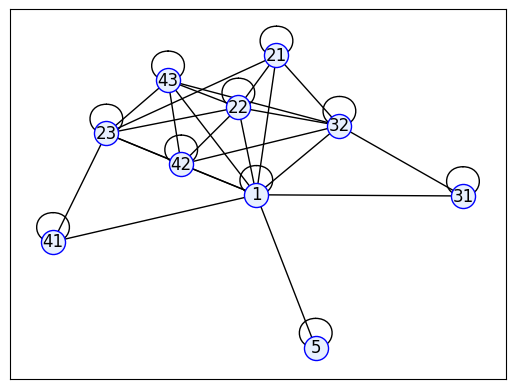

In [13]:
graph = nx.Graph()
graph.add_edges_from(edges4)

pos = nx.spring_layout(graph, seed=42)
nx.draw_networkx(graph, pos, node_color="#E8F0FF", edgecolors="blue", width=1)
plt.show()
